<a href="https://colab.research.google.com/github/khanhken159/vietnam-traffic-sign-detection/blob/main/yolov8_roboflow_colab_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: Train YOLOv8 trên Google Colab với dataset từ Roboflow

Notebook này gồm các phần đúng theo yêu cầu:
1. **Trình bày cách train model**
2. **Trình bày kết quả**
3. **Phân tích kết quả**
> Bạn chỉ cần thay `ROBOFLOW_API_KEY`, `WORKSPACE`, `PROJECT`, `VERSION` theo dataset của bạn trên Roboflow.


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Cập nhật đường dẫn đến folder DPL301c của bạn
DRIVE_OUTPUT_DIR = '/content/drive/MyDrive/DPL301c'
os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)
print(f"Kết quả sẽ được lưu tại: {DRIVE_OUTPUT_DIR}")

Mounted at /content/drive
Kết quả sẽ được lưu tại: /content/drive/MyDrive/DPL301c


In [ ]:
!nvidia-smi

Wed Jun 24 13:17:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Cài thư viện cần thiết

Notebook dùng `ultralytics` để train YOLOv8 và `roboflow` để tải dataset trực tiếp.

In [ ]:
!pip install -q ultralytics roboflow

import os
import glob
from pathlib import Path
from ultralytics import YOLO

print("Setup done!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 90.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Setup done!


## 2. Tải dataset từ Roboflow

Vào Roboflow project của bạn, chọn **Download Dataset → YOLOv8 → Show Download Code**, rồi thay thông tin bên dưới.

In [ ]:
!pip install roboflow


from roboflow import Roboflow
rf = Roboflow(api_key="CAUE5ZvN0FJDbsoi6moP")
project = rf.workspace("dngs-workspace-k3fml").project("vietnam-traffic-sign-altsi-durze")
version = project.version(4)
dataset = version.download("yolov8")


DATA_YAML = f"{dataset.location}/data.yaml"
print("Dataset location:", dataset.location)
print("data.yaml:", DATA_YAML)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Vietnam-Traffic-Sign-4 in yolov8:: 100%|██████████| 29607/29607 [00:12<00:00, 2302.29it/s]


Dataset location: /content/Vietnam-Traffic-Sign-4
data.yaml: /content/Vietnam-Traffic-Sign-4/data.yaml


## 3. Kiểm tra cấu trúc dataset

Dataset YOLOv8 thường có dạng:

```text
dataset/
├── train/images, train/labels
├── valid/images, valid/labels
├── test/images, test/labels
└── data.yaml
```

In [ ]:
print("Train images:", len(glob.glob(f"{dataset.location}/train/images/*")))
print("Valid images:", len(glob.glob(f"{dataset.location}/valid/images/*")))
print("Test images :", len(glob.glob(f"{dataset.location}/test/images/*")))

!cat {DATA_YAML}

Train images: 12190
Valid images: 1742
Test images : 869
names:
- DP-135
- P-102
- P-103a
- P-103b
- P-103c
- P-104
- P-106a
- P-106b
- P-107a
- P-112
- P-115
- P-117
- P-123a
- P-123b
- P-124a
- P-124b
- P-124c
- P-127
- P-128
- P-130
- P-131a
- P-137
- P-245a
- R-301c
- R-301d
- R-301e
- R-302a
- R-302b
- R-303
- R-407a
- R-409
- R-425
- R-434
- S-509a
- W-201a
- W-201b
- W-202a
- W-202b
- W-203b
- W-203c
- W-205a
- W-205b
- W-205d
- W-207a
- W-207b
- W-207c
- W-208
- W-209
- W-210
- W-219
- W-224
- W-225
- W-227
- W-233
- W-235
- W-245a
nc: 56
roboflow:
  license: CC BY 4.0
  project: vietnam-traffic-sign-altsi-durze
  url: https://universe.roboflow.com/dngs-workspace-k3fml/vietnam-traffic-sign-altsi-durze/dataset/4
  version: 4
  workspace: dngs-workspace-k3fml
test: ../test/images
train: ../train/images
val: ../valid/images


## 4. Kỹ thuật 1: Chọn model YOLOv8 phù hợp

| Model | Ưu điểm | Khi nào dùng |
|---|---|---|
| `yolov8n.pt` | nhanh, nhẹ | dataset nhỏ, chạy real-time, mobile |
| `yolov8s.pt` | cân bằng tốc độ và độ chính xác | lựa chọn phổ biến |
| `yolov8m.pt` | chính xác hơn | cần accuracy cao, GPU tốt |

Notebook này mặc định dùng `yolov8n.pt` để train nhanh trên Colab.

In [ ]:
MODEL_NAME = "yolov8s.pt"

model = YOLO(MODEL_NAME)
model.info()

YOLOv8s summary: 129 layers, 11,166,560 parameters, 0 gradients, 28.8 GFLOPs


(129, 11166560, 0, 28.816844800000002)

## 5. Kỹ thuật 2: Train baseline model

Đây là lần train đầu tiên để lấy kết quả nền.

Tham số quan trọng:
- `imgsz`: kích thước ảnh đầu vào
- `epochs`: số vòng train
- `batch`: batch size
- `patience`: early stopping nếu model không cải thiện

In [ ]:
# Chạy tiếp (resume) hoặc train mới lưu vào folder DPL301c trên Drive
results = model.train(
    data=DATA_YAML,
    epochs=20,
    imgsz=640,
    batch=16,
    patience=10,
    workers=2,
    project=DRIVE_OUTPUT_DIR, # Lưu vào folder DPL301c
    name="yolov8_baseline",
    exist_ok=True,
    resume=True # Tự động chạy tiếp nếu có checkpoint trong folder
)

WARNING ⚠️ model 'yolov8s.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Vietnam-Traffic-Sign-4/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300

## 7. Kỹ thuật 3: Fine-tune với learning rate nhỏ hơn

Sau khi train xong, tiếp tục fine-tune từ model tốt nhất với learning rate nhỏ hơn để giảm loss ổn định hơn và cải thiện mAP.

In [ ]:
import os

# Cập nhật đường dẫn đến file best.pt từ bước train baseline trước đó
BEST_AUG_MODEL = os.path.join(DRIVE_OUTPUT_DIR, "yolov8_baseline/weights/best.pt")

if os.path.exists(BEST_AUG_MODEL):
    model_finetune = YOLO(BEST_AUG_MODEL)

    results_finetune = model_finetune.train(
        data=DATA_YAML,
        epochs=10,
        imgsz=640,
        batch=16,
        patience=5,
        workers=2,
        lr0=0.001,
        lrf=0.01,
        mosaic=0.3,
        project=DRIVE_OUTPUT_DIR,
        name="yolov8_finetune",
        exist_ok=True
    )
else:
    print(f"Lỗi: Không tìm thấy file tại {BEST_AUG_MODEL}. Vui lòng kiểm tra lại quá trình train ở bước 5.")

New https://pypi.org/project/ultralytics/8.4.76 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Vietnam-Traffic-Sign-4/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/DPL301c/yolov8_baseline/weig

## 8. Trình bày kết quả validation

| Chỉ số | Ý nghĩa |
|---|---|
| Precision | Trong các object model dự đoán, bao nhiêu cái đúng |
| Recall | Trong các object thật, model tìm được bao nhiêu |
| mAP50 | độ chính xác trung bình ở IoU 0.5 |
| mAP50-95 | chỉ số khắt khe hơn, trung bình từ IoU 0.5 đến 0.95 |

`mAP50-95` càng cao thì model càng tốt.

In [ ]:
import os

# Đường dẫn model tốt nhất sau khi fine-tune
BEST_MODEL = os.path.join(DRIVE_OUTPUT_DIR, "yolov8_finetune/weights/best.pt")

if os.path.exists(BEST_MODEL):
    trained_model = YOLO(BEST_MODEL)
    # Thực hiện validation trên tập val
    metrics = trained_model.val(data=DATA_YAML, imgsz=640, split="val")

    print("mAP50:", metrics.box.map50)
    print("mAP50-95:", metrics.box.map)
    print("Precision:", metrics.box.mp)
    print("Recall:", metrics.box.mr)
else:
    print(f"Lỗi: Không tìm thấy file tại {BEST_MODEL}. Vui lòng kiểm tra lại bước 7.")

Ultralytics 8.4.76 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 11,147,256 parameters, 0 gradients, 28.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1379.0±699.0 MB/s, size: 76.2 KB)
val: Scanning /content/Vietnam-Traffic-Sign-4/valid/labels... 1742 images, 99 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1742/1742 538.8it/s 3.2s
val: New cache created: /content/Vietnam-Traffic-Sign-4/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 109/109 13.6s/it 24:46
                   all       1742       3392       0.96      0.963      0.978      0.874
                DP-135         10         10      0.959          1      0.995      0.918
                 P-102        150        154      0.965      0.902      0.938      0.729
                P-103a         40         40      0.995          1      0.995      0.874
                P-103b          8          

In [ ]:
import pandas as pd

# Load the baseline model and evaluate its metrics
BASELINE_MODEL = os.path.join(DRIVE_OUTPUT_DIR, "yolov8_baseline/weights/best.pt")

if os.path.exists(BASELINE_MODEL):
    baseline_trained_model = YOLO(BASELINE_MODEL)
    baseline_metrics = baseline_trained_model.val(data=DATA_YAML, imgsz=640, split="val")

    baseline_summary = pd.DataFrame({
        "Metric": ["Precision", "Recall", "mAP50", "mAP50-95"],
        "Baseline Value": [
            float(baseline_metrics.box.mp),
            float(baseline_metrics.box.mr),
            float(baseline_metrics.box.map50),
            float(baseline_metrics.box.map)
        ],
    })

    # Combine with the finetune model results from the previous cell ('summary' DataFrame)
    comparison_summary = pd.merge(baseline_summary, summary, on="Metric")
    comparison_summary.rename(columns={'Value': 'Finetune Value'}, inplace=True)
    display(comparison_summary)
else:
    print(f"Lỗi: Không tìm thấy file tại {BASELINE_MODEL}. Vui lòng kiểm tra lại quá trình train ở bước 5.")

Ultralytics 8.4.76 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 11,147,256 parameters, 0 gradients, 28.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 24.7±8.4 MB/s, size: 82.6 KB)
val: Scanning /content/Vietnam-Traffic-Sign-4/valid/labels.cache... 1742 images, 99 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1742/1742 42.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 109/109 13.1s/it 23:43
                   all       1742       3392      0.933      0.975      0.977      0.865
                DP-135         10         10      0.948          1      0.995      0.943
                 P-102        150        154      0.959      0.913      0.946      0.741
                P-103a         40         40      0.982          1      0.995      0.882
                P-103b          8          8       0.95          1      0.995      0.995
                P-103c     

,Metric,Baseline Value,Finetune Value,Meaning
0,Precision,0.932706,0.960131,Tỷ lệ dự đoán đúng trong các object model phát...
1,Recall,0.974544,0.962820,Tỷ lệ object thật được model phát hiện
2,mAP50,0.976607,0.978179,Độ chính xác trung bình tại IoU 0.5
3,mAP50-95,0.864619,0.874076,Độ chính xác trung bình từ IoU 0.5 đến 0.95


## 9. Hiển thị biểu đồ kết quả train

YOLOv8 tự lưu các hình:
- `results.png`: loss, precision, recall, mAP
- `confusion_matrix.png`: ma trận nhầm lẫn
- `PR_curve.png`: precision-recall curve
- `F1_curve.png`: F1 curve

Hiển thị: results.png


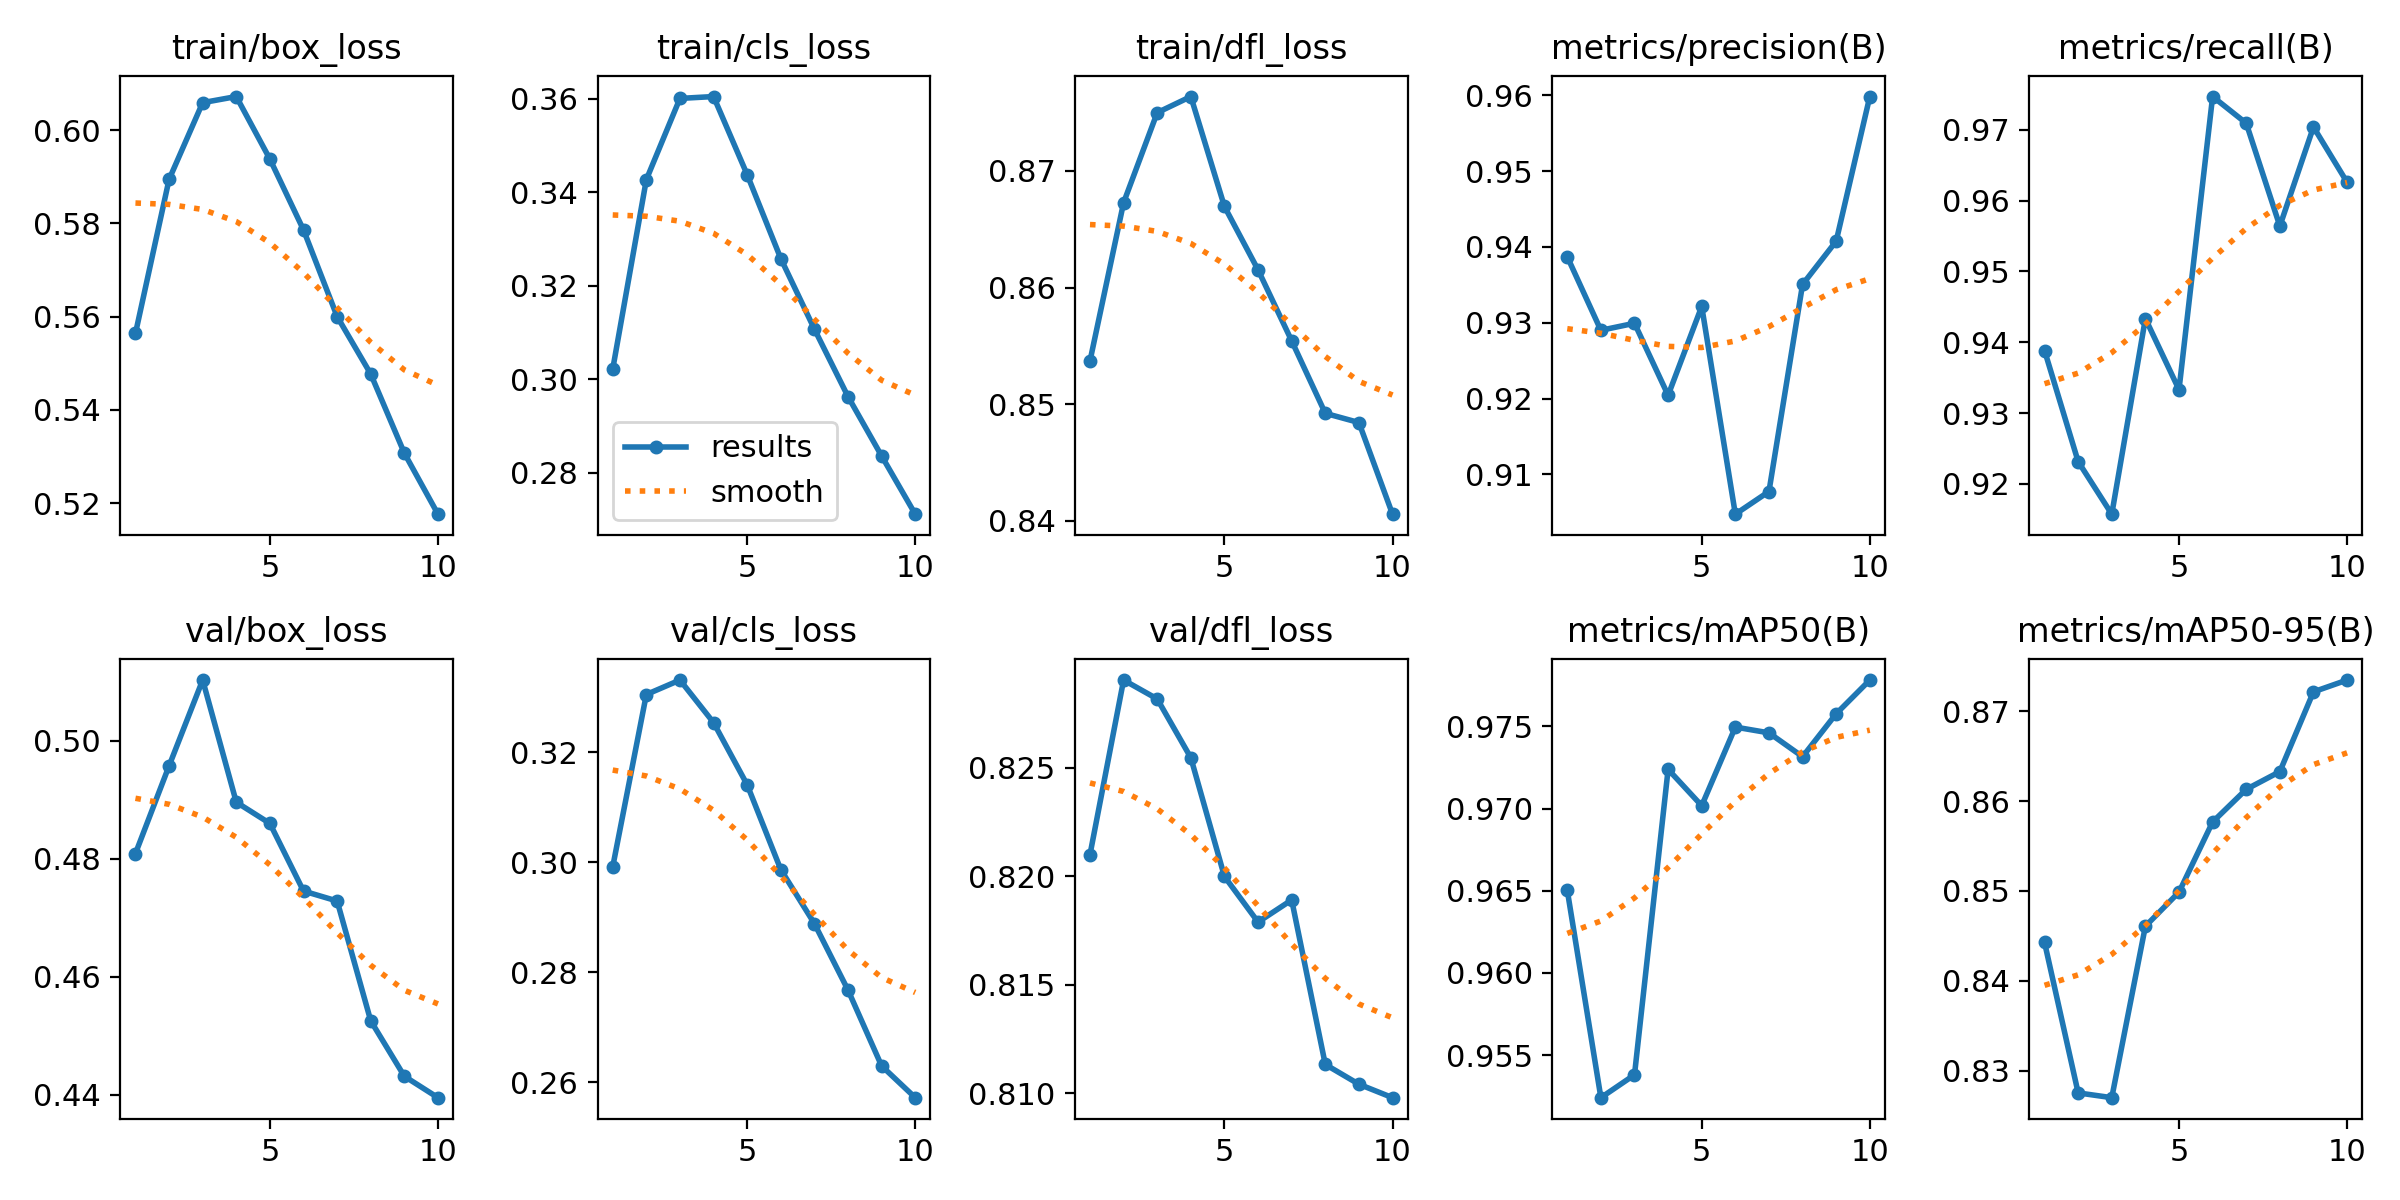

Hiển thị: confusion_matrix.png


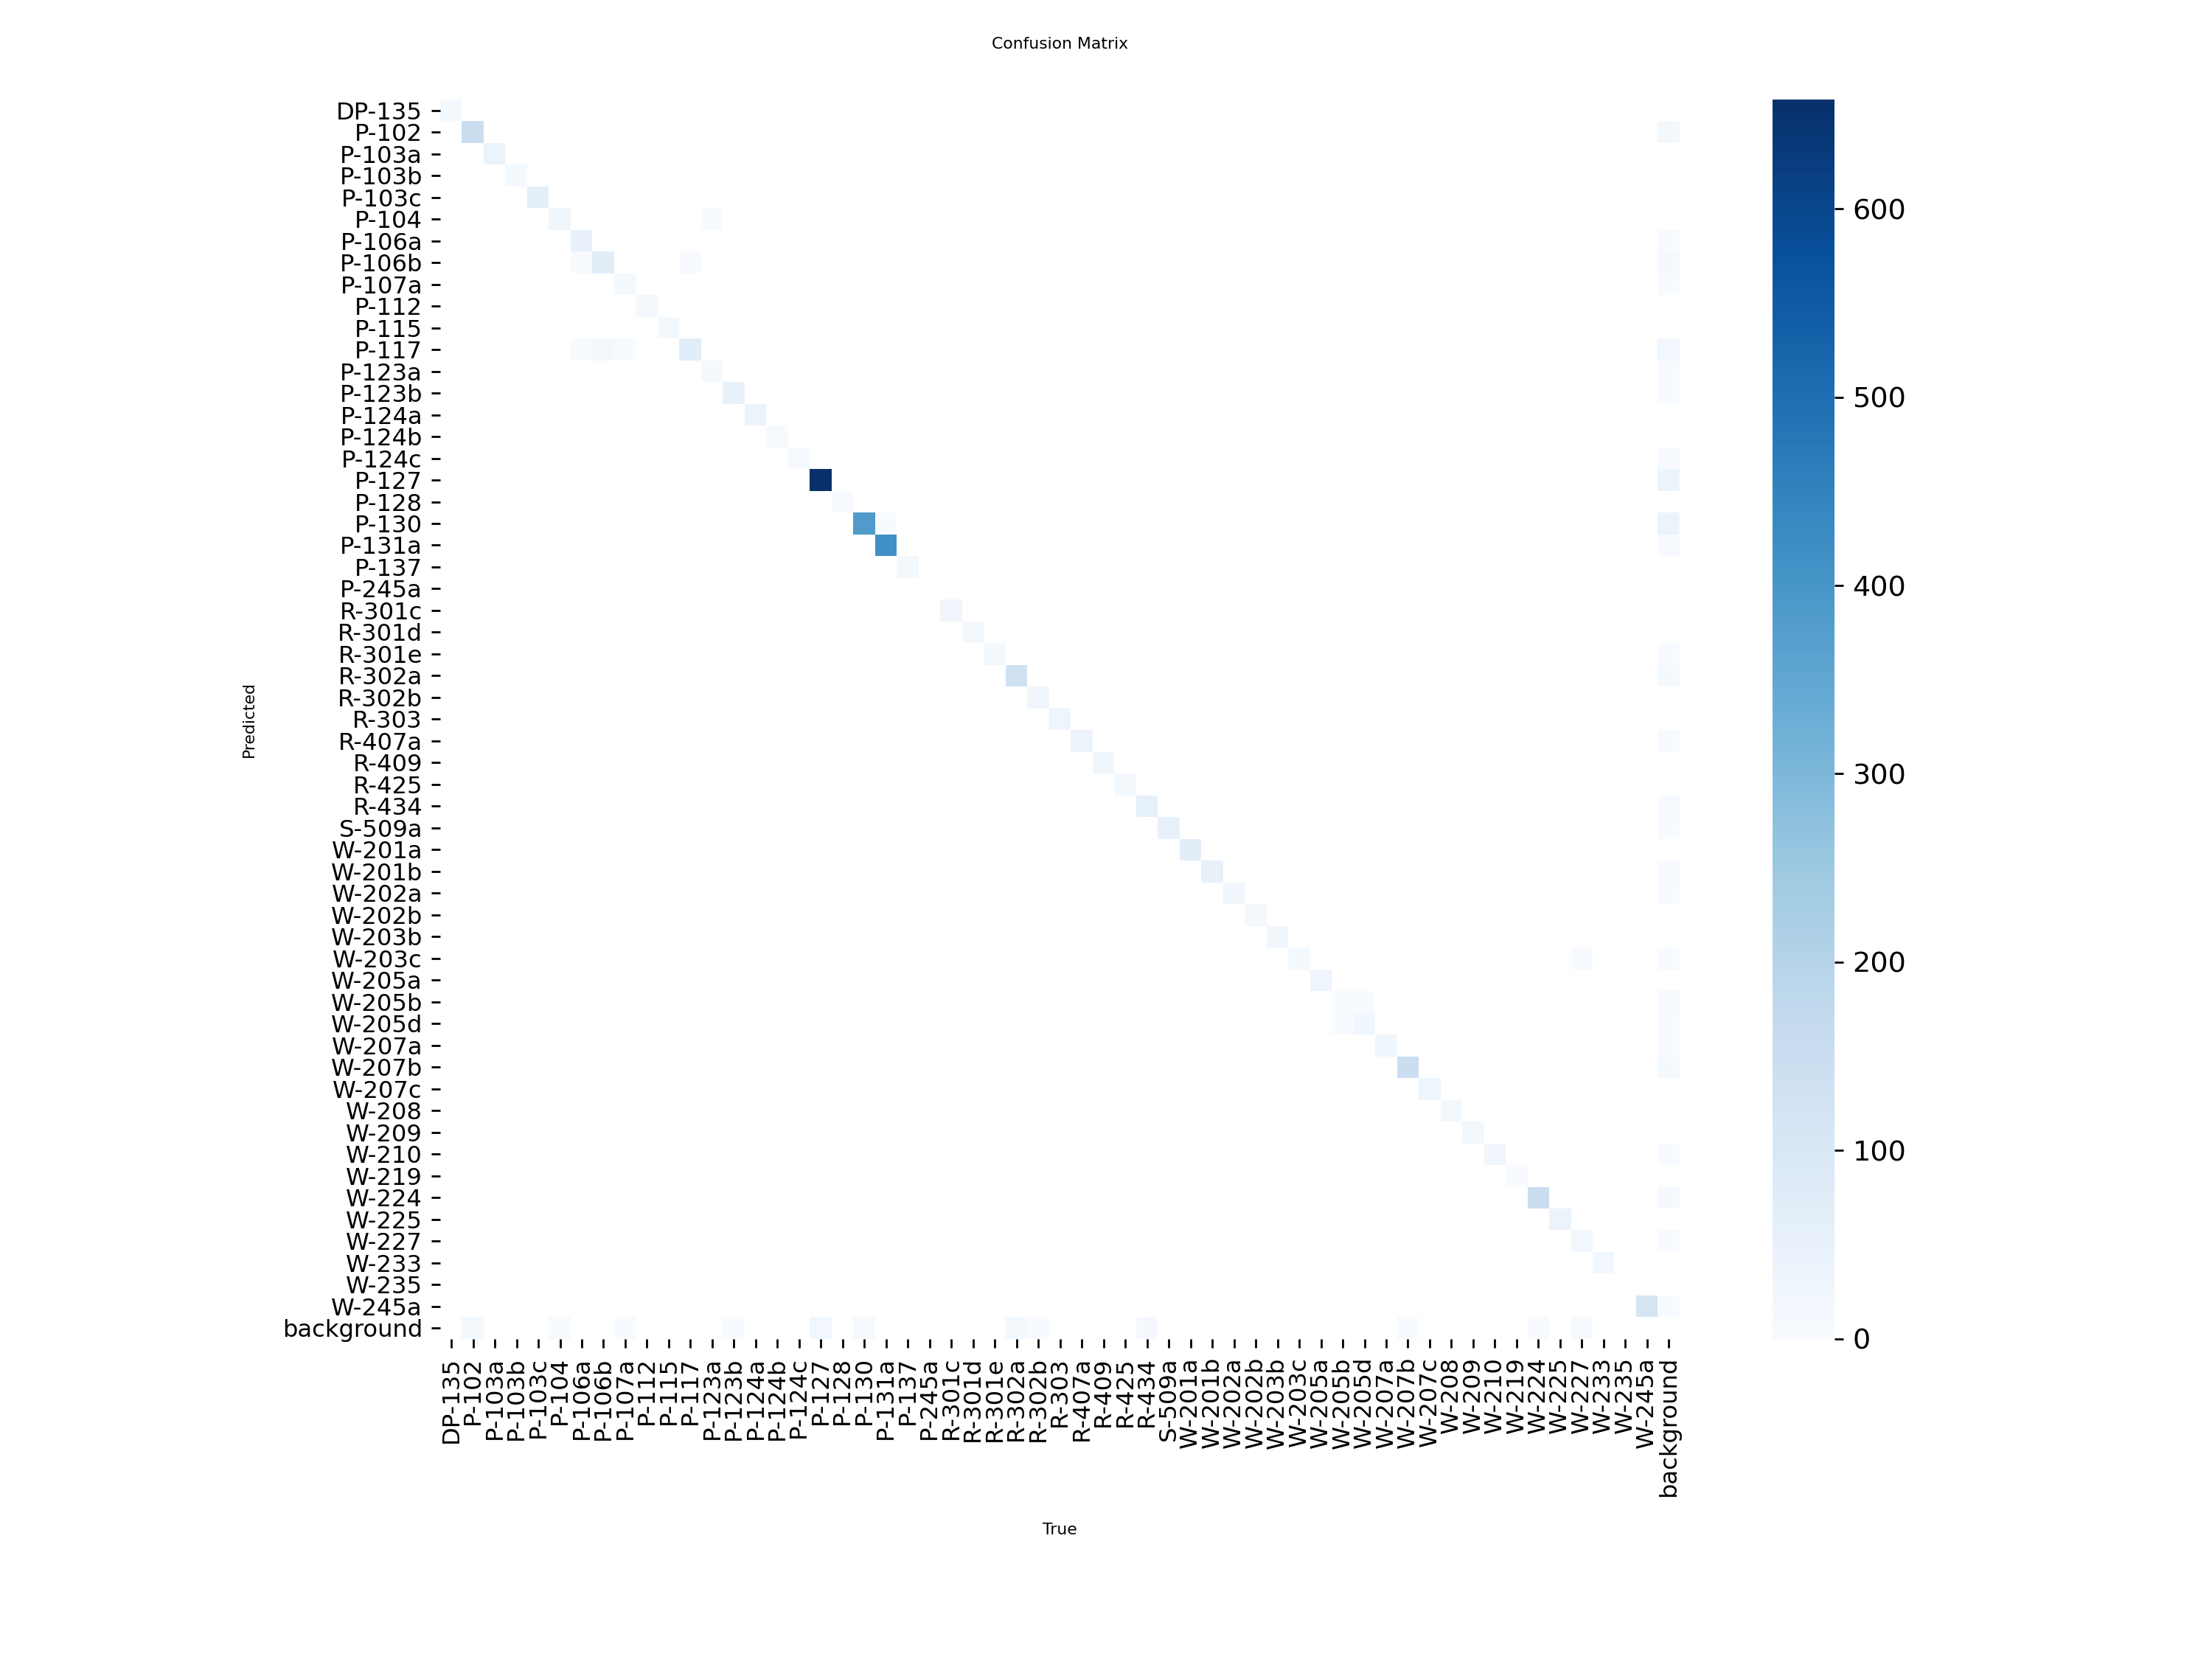

Cảnh báo: Không tìm thấy file biểu đồ tại /content/drive/MyDrive/DPL301c/yolov8_finetune/PR_curve.png
Cảnh báo: Không tìm thấy file biểu đồ tại /content/drive/MyDrive/DPL301c/yolov8_finetune/F1_curve.png


In [ ]:
from IPython.display import Image, display
import os

# Trỏ vào thư mục kết quả fine-tune trên Drive
run_dir = os.path.join(DRIVE_OUTPUT_DIR, "yolov8_finetune")

results_files = ["results.png", "confusion_matrix.png", "PR_curve.png", "F1_curve.png"]

for file in results_files:
    path = os.path.join(run_dir, file)
    if os.path.exists(path):
        print(f"Hiển thị: {file}")
        display(Image(filename=path, width=900))
    else:
        print(f"Cảnh báo: Không tìm thấy file biểu đồ tại {path}")

## 10. Test model trên ảnh test

Phần này dùng model đã train để dự đoán trên tập test.

In [ ]:
test_images = glob.glob(f"{dataset.location}/test/images/*")

print("Số ảnh test:", len(test_images))
print("Ví dụ ảnh test:", test_images[:3])

Số ảnh test: 869
Ví dụ ảnh test: ['/content/Vietnam-Traffic-Sign-4/test/images/IMG_4181-MOV_out0005_png_jpg.rf.28d5c35dacb3eae6fa32aee0626a71b8.jpg', '/content/Vietnam-Traffic-Sign-4/test/images/IMG_4112-MOV_out0073_png_jpg.rf.9a5b6fe87e7b1cc3ef24f61c9433c7a5.jpg', '/content/Vietnam-Traffic-Sign-4/test/images/IMG_4007-MOV_out0189_png_jpg.rf.46dd22b39638b921dd5a01973e2e1793.jpg']


In [ ]:
# @title
# Dự đoán trên tập test và lưu kết quả vào Drive để không bị mất khi reset runtime
predict_results = trained_model.predict(
    source=os.path.join(dataset.location, "test/images"),
    imgsz=640,
    conf=0.25,
    save=True,
    project=DRIVE_OUTPUT_DIR,
    name="test_predictions",
    exist_ok=True
)

print(f"Kết quả dự đoán đã được lưu tại: {os.path.join(DRIVE_OUTPUT_DIR, 'test_predictions')}")


image 1/869 /content/Vietnam-Traffic-Sign-4/test/images/IMG_4004-MOV_out0001_png_jpg.rf.69b22c37000fc67da393e91ec2febe3d.jpg: 640x640 1 P-102, 1 R-302a, 1 W-207c, 777.7ms
image 2/869 /content/Vietnam-Traffic-Sign-4/test/images/IMG_4004-MOV_out0001_png_jpg.rf.9cd5d915658a66bf5bbd3316557b500f.jpg: 640x640 1 P-102, 1 R-302a, 1 W-207c, 724.2ms
image 3/869 /content/Vietnam-Traffic-Sign-4/test/images/IMG_4004-MOV_out0003_png_jpg.rf.69bba69c5d5ea45f986f4915cea820a4.jpg: 640x640 1 P-102, 1 R-302a, 1 W-207c, 690.8ms
image 4/869 /content/Vietnam-Traffic-Sign-4/test/images/IMG_4004-MOV_out0005_png_jpg.rf.d7232ebfb21bd78c70942ef420ccf3dd.jpg: 640x640 1 P-102, 1 R-302a, 1 W-207c, 1276.3ms
image 5/869 /content/Vietnam-Traffic-Sign-4/test/images/IMG_4004-MOV_out0005_png_jpg.rf.e943416a22322a7158d1f9b52d8c4e8c.jpg: 640x640 1 P-102, 1 R-302a, 1 W-207c, 1130.3ms
image 6/869 /content/Vietnam-Traffic-Sign-4/test/images/IMG_4004-MOV_out0027_png_jpg.rf.188ff09ce1bf2815bd2f7826dc5cb346.jpg: 640x640 1 P-102,

Tìm thấy 869 ảnh đã dự đoán. Hiển thị 5 ảnh ngẫu nhiên:


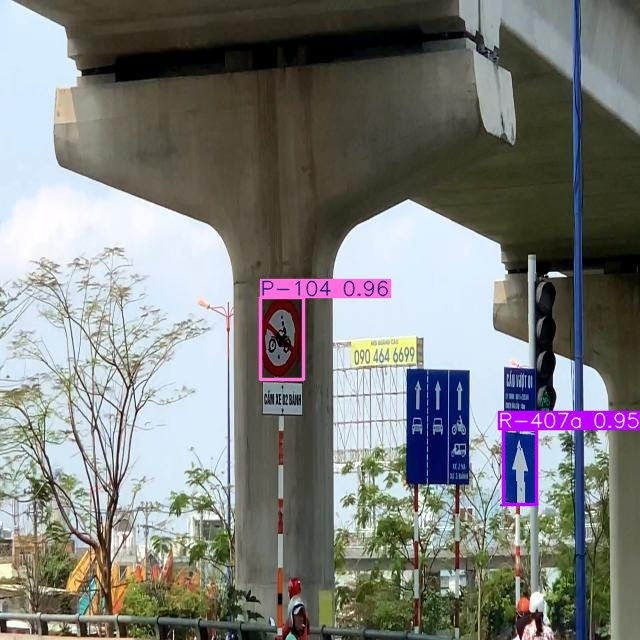

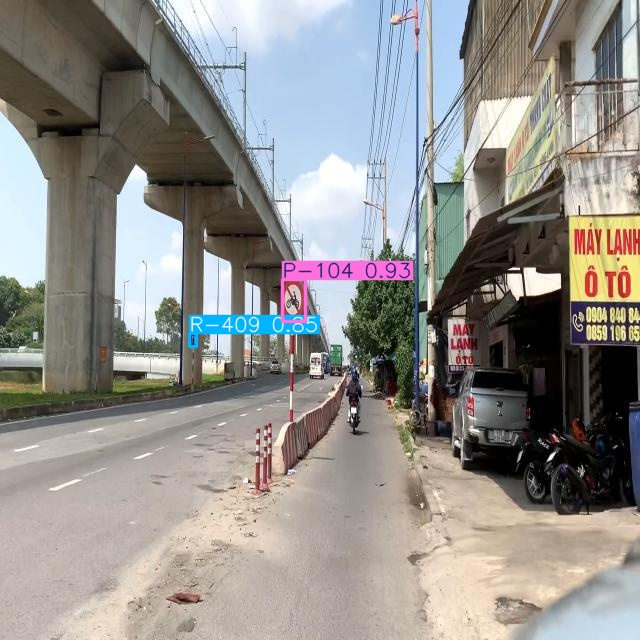

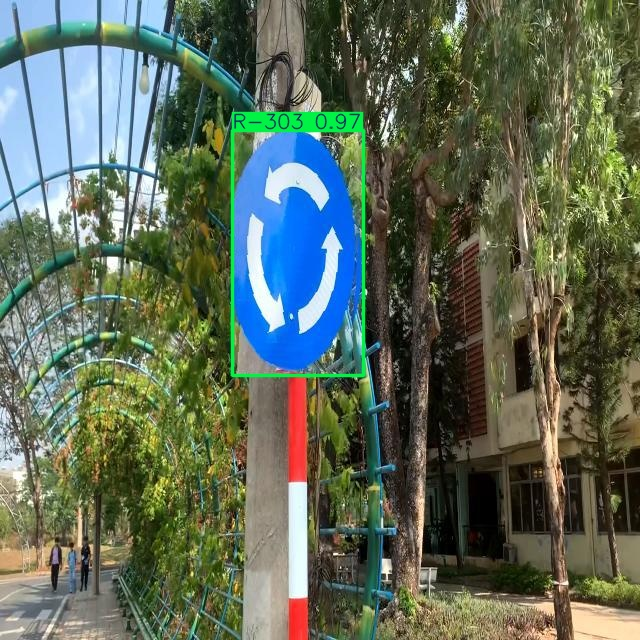

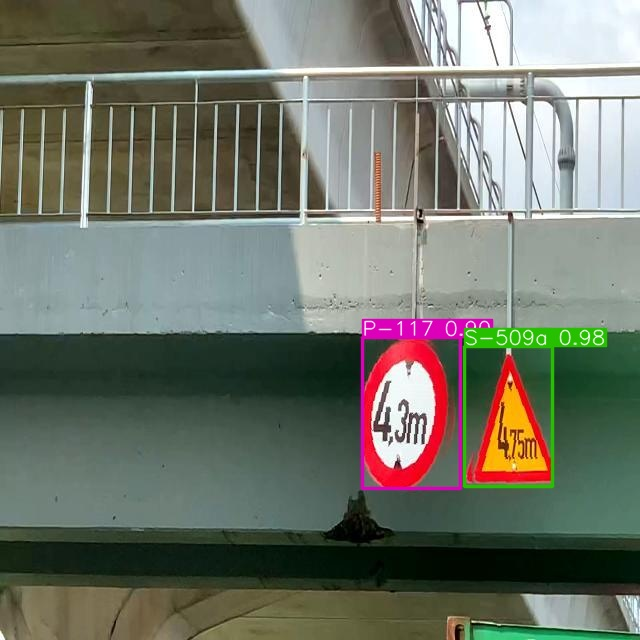

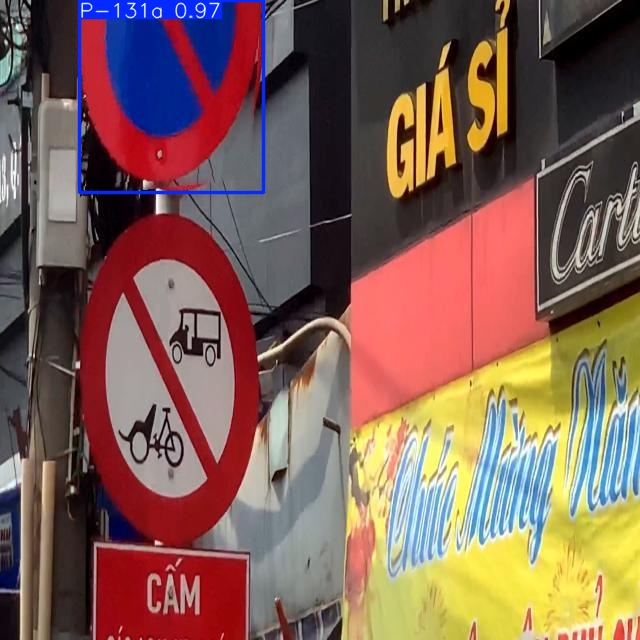

In [ ]:
import glob
import random
from IPython.display import Image, display

# Đường dẫn đến thư mục chứa ảnh đã được model vẽ bounding box
pred_dir = os.path.join(DRIVE_OUTPUT_DIR, "test_predictions")
pred_imgs = glob.glob(os.path.join(pred_dir, "*"))

if len(pred_imgs) > 0:
    # Chọn ngẫu nhiên 5 ảnh để hiển thị đa dạng hơn
    sample_size = min(5, len(pred_imgs))
    random_samples = random.sample(pred_imgs, sample_size)

    print(f"Tìm thấy {len(pred_imgs)} ảnh đã dự đoán. Hiển thị {sample_size} ảnh ngẫu nhiên:")
    for img_path in random_samples:
        display(Image(filename=img_path, width=700))
else:
    print(f"Không tìm thấy ảnh dự đoán nào trong {pred_dir}")

## 11. Phân tích kết quả

### 11.1 Nhận xét chung
Model YOLOv8 đã học được đặc trưng của đối tượng trong dataset. Nếu `mAP50` cao nhưng `mAP50-95` thấp, nghĩa là model nhận ra object khá tốt nhưng bounding box chưa thật sự chính xác.

### 11.2 Phân tích Precision và Recall
- Precision cao: model ít dự đoán sai.
- Recall cao: model ít bỏ sót object.
- Precision thấp: model hay nhận nhầm background thành object.
- Recall thấp: model bỏ sót nhiều object thật.

### 11.3 Phân tích loss
- `box_loss` giảm: model học bounding box tốt hơn.
- `cls_loss` giảm: model phân loại class tốt hơn.
- `dfl_loss` giảm: model định vị box ổn định hơn.
- Nếu train loss giảm nhưng val loss tăng, model có thể bị overfitting.

### 11.4 Phân tích confusion matrix
Dùng confusion matrix để xem class nào bị nhầm nhiều nhất. Nếu một class bị nhầm nhiều, có thể do ảnh quá giống class khác, thiếu dữ liệu, label chưa chính xác, object quá nhỏ hoặc bị che khuất.

In [ ]:
import pandas as pd

summary = pd.DataFrame({
    "Metric": ["Precision", "Recall", "mAP50", "mAP50-95"],
    "Value": [
        float(metrics.box.mp),
        float(metrics.box.mr),
        float(metrics.box.map50),
        float(metrics.box.map)
    ],
    "Meaning": [
        "Tỷ lệ dự đoán đúng trong các object model phát hiện",
        "Tỷ lệ object thật được model phát hiện",
        "Độ chính xác trung bình tại IoU 0.5",
        "Độ chính xác trung bình từ IoU 0.5 đến 0.95"
    ]
})

summary

,Metric,Value,Meaning
0,Precision,0.960131,Tỷ lệ dự đoán đúng trong các object model phát...
1,Recall,0.962820,Tỷ lệ object thật được model phát hiện
2,mAP50,0.978179,Độ chính xác trung bình tại IoU 0.5
3,mAP50-95,0.874076,Độ chính xác trung bình từ IoU 0.5 đến 0.95
